### python End to End project
# "DEPI Python Project: Exploratory Data Analysis & Insights" #

**project objective:** A multinational retail company wants an automated analytical solution to monitor sales, profitability, customer behavior, and operational performance.

**Key business questions:**


##  Tools & Libraries Used
- **Language:** Python
- **Libraries:** Pandas, NumPy, Matplotlib, Seaborn , scipy

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp

### **first: Data Exploring and Cleaning**

In [14]:
# data loading
df = pd.read_excel("File 1.xlsx")

c:\Users\HANA\anaconda3\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


In [19]:
# First look at the data shape
df.shape

(9994, 21)

In [17]:
# looking at 5 random samples of the data
df.sample(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
1837,1838,CA-2016-117345,2016-08-01,2016-08-05,Standard Class,BF-10975,Barbara Fisher,Corporate,United States,Charlotte,...,28205.0,South,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,17.544,3,0.20,5.9211
8973,8974,CA-2019-159226,2019-04-25,2019-04-27,Second Class,RL-19615,Rob Lucas,Consumer,United States,Los Angeles,...,90008.0,West,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",344.981,7,0.15,28.4102
8225,8226,CA-2019-104136,2019-11-01,2019-11-04,Second Class,SF-20065,Sandra Flanagan,Consumer,United States,Everett,...,2149.0,East,OFF-PA-10004243,Office Supplies,Paper,Xerox 1939,189.700,10,0.00,91.0560
4460,4461,US-2019-125717,2019-09-28,2019-10-01,First Class,DS-13030,Darrin Sayre,Home Office,United States,Aurora,...,80013.0,West,OFF-ST-10001522,Office Supplies,Storage,"Gould Plastics 18-Pocket Panel Bin, 34w x 5-1/...",147.184,2,0.20,-29.4368
6598,6599,CA-2016-169257,2016-06-06,2016-06-12,Standard Class,SV-20785,Stewart Visinsky,Consumer,United States,Jacksonville,...,32216.0,South,OFF-PA-10002319,Office Supplies,Paper,Xerox 1944,62.016,2,0.20,22.4808


In [11]:
# looking at the columns
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [12]:
# information about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9994 non-null   int64         
 1   Order ID        9994 non-null   object        
 2   Order Date      9994 non-null   datetime64[ns]
 3   Ship Date       9994 non-null   datetime64[ns]
 4   Ship Mode       9994 non-null   object        
 5   Customer ID     9994 non-null   object        
 6   Customer Name   9994 non-null   object        
 7   Segment         9994 non-null   object        
 8   Country/Region  9994 non-null   object        
 9   City            9994 non-null   object        
 10  State           9994 non-null   object        
 11  Postal Code     9983 non-null   float64       
 12  Region          9994 non-null   object        
 13  Product ID      9994 non-null   object        
 14  Category        9994 non-null   object        
 15  Sub-

In [18]:
# is there any duplicated data?
df.duplicated().sum()

np.int64(0)

- ***there is no duplicated data !***

In [42]:
# looking at the unique values in each column
df.nunique()

Row ID            9994
Order ID          5009
Order Date        1236
Ship Date         1334
Ship Mode            4
Customer ID        793
Customer Name      793
Segment              3
Country/Region       1
City               531
State               49
Postal Code        631
Region               4
Product ID        1862
Category             3
Sub-Category        17
Product Name      1850
Sales             6144
Quantity            14
Discount            12
Profit            7545
dtype: int64

**what to notice?**
1. we have only one [country/region] and (531) [city] and (49) [state] and (4) [region]
2. we have just 3 segment

In [24]:
# is there any missing values in the data?
df.isna().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State             0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

- ***we have 11 missing values in col(Postal Code)***

## handling missing values

**the only column with missing values is [postal_code] with 11 missing values**
- so we can fill the missing values with (" UNKNOWN ") so that we can keep the data and not lose any information

In [27]:
df["Postal Code"] = df["Postal Code"].fillna("UNKNOWN") 

# Analysing and Insightful Insights

In [26]:
# 1. describing 
df.describe()

,Row ID,Order Date,Ship Date,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2018-04-30 10:03:51.979187712,2018-05-04 09:03:29.645787392,229.858001,3.789574,0.156203,28.656896
min,1.000000,2016-01-03 00:00:00,2016-01-07 00:00:00,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2017-05-23 00:00:00,2017-05-27 00:00:00,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2018-06-26 00:00:00,2018-06-29 00:00:00,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2019-05-14 00:00:00,2019-05-18 00:00:00,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2019-12-30 00:00:00,2020-01-05 00:00:00,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,623.245101,2.225110,0.206452,234.260108


 ## insights about the data
- 1. the Mean in [Sales] is (229.85) while the Median is ( 54.49) , which indicates that the data is right-skewed  
which means that there are some extreme values in the data that are affecting the mean.
- 2. the min profit is (-6599.98) which mean that there are some products that are not profitable and are causing losses to the company.
- 3. the most discount given is (0.8) (80%)  wich is very high and it may cause losses to the company if it is not managed properly.

## - Handaling Outliers 

In [32]:
# cancellation (negative quantity) and sales outliers
df_clean = df[(df["Quantity"]>0) & (df["Sales"]>0)].copy()

In [34]:
# Outlier detection via IQR on Sales
Q1, Q3 = df_clean["Sales"].quantile([0.25,0.75])
IQR = Q3-Q1
upper_limit = Q3 + 1.5*IQR
lower_limit = Q1 - 1.5*IQR

outliers = df_clean[(df_clean["Sales"]>upper_limit) | (df_clean["Sales"]<lower_limit)]
print (f"{len(outliers)} rows {len(outliers)/len(df_clean):.1%} flagged as outliers")

1167 rows 11.7% flagged as outliers


In [39]:
# Keep but flag rather than blindly drop — bulk orders may be legitimate whole sale
df_clean["is_bulk_outlier"] = df_clean["Sales"] > upper_limit

In [40]:
df_clean

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,is_bulk_outlier
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,False
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,True
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,False
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,True
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2016-110422,2016-01-21,2016-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,False
9990,9991,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332,False
9991,9992,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932,False
9992,9993,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200,False


## Key Business Questions Addressed
1. **Top Geographical Performance (top_geo_per_month):** Identifies the highest sales-generating State/Region for each month across the multi-year dataset.
2. **Seasonality & Demand Shifts (seasonal_analysis):** Evaluates sales revenue, total profit, order volume, and Average Order Value (AOV) across standard meteorological seasons (**Winter**, **Spring**, **Summer**, **Fall**).
3. **Customer Activity Tiers (customer_activity_analysis):** Segments customer base based on order frequency into 3 balanced activity tiers (**Low**, **Medium**, **High**) using Quantile Discretization (`pd.qcut`, `q=3`).

In [ ]:
 # first lets create class to analyze the sales date by country, state, region, city, and county.

from typing import Self


class SalesMarketAnalyze:
        def __init__(self, df: pd.DataFrame, geo_col: str = "State"):
            # geo_col: Geographic column to group by ('State', 'Region', 'City', 'county')
            # If 'Country/Region' contains only 1 unique value, it falls back to 'State'.
            self.df = df.copy()  # to not affect the main document

            if geo_col in self.df.columns and self.df[geo_col].nunique() == 1:
                print(
                    f"Note: '{geo_col}' contains only 1 unique value "
                    f"({self.df[geo_col].iloc[0]}). Defaulting to 'State'."
                )
                self.geo_col = 'State' if 'State' in self.df.columns else 'Region'
            else:
                self.geo_col = geo_col if geo_col in self.df.columns else 'State'

            self._prepare_datetime_features()
        def _prepare_datetime_features(self):
             # Convert 'Order Date' to datetime and extract year, month, and day
             self.df["Order Date"] = pd.to_datetime(self.df["Order Date"])
             self.df["Year"] = self.df["Order Date"].dt.year
             self.df["Month"] = self.df["Order Date"].dt.month
             self.df['Month_Name'] = self.df['Order Date'].dt.strftime ('%b')
             self.df['Year_Month'] = self.df['Order Date'].dt.to_period('M')
             self.df['Day_of_Week'] = self.df['Order Date'].dt.day_name()

             # Categorize months into standard meteorological seasons 
             def categorize_season(month):
                  if month in [12 , 1 , 2]:
                       return "winter"

                  elif month in [3 , 4 , 5]:
                       return "spring"

                  elif month in [6 , 7 , 8]:
                       return "summer" 
                  else:
                       return "autumn"
             self.df['Season'] = self.df['Month'].apply(categorize_season)
        
        def top_geo_by_month(self, top_n: int = 5):
              #Identifies top performing States/Regions by total sales for each year-month.
               #top_n: Number of top locations to display per month (default = 5).

            monthly_geo = self.df.groupby(["Year_Month", self.geo_col])["Sales"].sum().reset_index()
        
             # Rank locations per month based on sales
            top_monthly = (
            monthly_geo.sort_values(['Year_Month', 'Sales'], ascending=[True, False])
            .groupby('Year_Month')
            .head(top_n)
            .reset_index(drop=True)
            ) 
            return top_monthly
        #Aggregates total sales, profit, order count, and average order value across seasons.

        def seasonal_performance(self):
            seasonal_summary = (
                self.df.groupby("Season")
                .agg(
            total_sales=("Sales", "sum"),
            total_profit=("Profit", "sum"),
            order_count=("Order ID", "nunique"),
            avg_order_value=("Sales", "mean"),
              ) 
             )
            return seasonal_summary

        
        def customer_activity_analysis(self):
             #Analyzes customer order frequency and segments customers using quantile binning (q=3)     
             customer_summary = (
            self.df.groupby('Customer ID')
            .agg(
                Total_Spent=('Sales', 'sum'),
                Total_Orders=('Order ID', 'nunique'),
                Avg_Basket_Size=('Quantity', 'sum'),
                Preferred_Segment=('Segment', lambda x: x.mode()[0] if not x.empty else 'N/A')
                )
            .reset_index()
             )
        
        # Classify customers into 3 equal-sized activity tiers based on order rank
             customer_summary['Activity_Level'] = pd.qcut(
            customer_summary['Total_Orders'].rank(method='first'), 
            q=3, 
            labels=['Low Activity', 'Medium Activity', 'High Activity']
        )
             return customer_summary
        

              
            

In [ ]:
# object instantiation
analyzer = SalesMarketAnalyze(df, geo_col="State")

In [54]:
# top states by month
top_states_by_month = analyzer.top_geo_by_month(top_n=5)
print("Table 1: Top Sales-Generating State Per Month")
display(top_states_by_month , df.head(12))

Table 1: Top Sales-Generating State Per Month


,Year_Month,State,Sales
0,2016-01,Kentucky,4374.880
1,2016-01,California,2455.185
2,2016-01,Arkansas,1859.400
3,2016-01,Louisiana,1287.260
4,2016-01,Virginia,999.440
...,...,...,...
235,2019-12,California,19318.023
236,2019-12,New York,6705.378
237,2019-12,Kentucky,4113.580
238,2019-12,Michigan,4039.810


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
5,6,CA-2016-115812,2016-06-09,2016-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
6,7,CA-2016-115812,2016-06-09,2016-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,4,0.00,1.9656
7,8,CA-2016-115812,2016-06-09,2016-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032.0,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
8,9,CA-2016-115812,2016-06-09,2016-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032.0,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,3,0.20,5.7825
9,10,CA-2016-115812,2016-06-09,2016-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032.0,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,0.00,34.4700


In [56]:
#(Seasonal Performance)
seasonal_summary_df = analyzer.seasonal_performance()

print("Table 2: Performance Summary Across Seasons")
display(seasonal_summary_df)

Table 2: Performance Summary Across Seasons


,total_sales,total_profit,order_count,avg_order_value
Season,,,,
autumn,860434.0014,104109.9431,1858,234.259189
spring,497796.4291,62593.4313,1066,237.158851
summer,459000.8393,56895.3986,1043,215.190267
winter,479969.5905,62798.2487,1042,229.760455


- ***autumn is the season with the highest total sales and profit, while winter has the lowest
 This suggests that the business experiences a seasonal trend, with peak performance in autumn and a dip in winter.
but if looking at the AOV , spring has the highest AOV, while summer has the lowest.*** 

In [62]:
#(Customer Activity)
customer_activity_df = analyzer.customer_activity_analysis()

print(" Table 3: Customer Activity & Segmentation Sample")
display(customer_activity_df.sort_values("Total_Spent", ascending=False).head(15))

 Table 3: Customer Activity & Segmentation Sample


,Customer ID,Total_Spent,Total_Orders,Avg_Basket_Size,Preferred_Segment,Activity_Level
700,SM-20320,25043.050,5,50,Home Office,Medium Activity
741,TC-20980,19052.218,5,42,Corporate,Medium Activity
621,RB-19360,15117.339,6,71,Consumer,Medium Activity
730,TA-21385,14595.620,4,36,Home Office,Low Activity
6,AB-10105,14473.571,10,73,Consumer,High Activity
434,KL-16645,14175.229,12,113,Consumer,High Activity
669,SC-20095,14142.334,9,87,Consumer,High Activity
327,HL-15040,12873.298,6,50,Consumer,Medium Activity
683,SE-20110,12209.438,11,78,Consumer,High Activity
131,CC-12370,12129.072,5,34,Consumer,Low Activity


In [68]:
#(Customer Activity)
segment_crosstab = pd.crosstab(
    customer_activity_df['Preferred_Segment'], 
    customer_activity_df['Activity_Level'],
    margins=True,
    normalize='index' 
) * 100

print("Percentage Breakdown of Activity Tiers Within Each Segment (%):")
display(segment_crosstab.sort_values(by="High Activity", ascending=False))

Percentage Breakdown of Activity Tiers Within Each Segment (%):


Activity_Level,Low Activity,Medium Activity,High Activity
Preferred_Segment,,,
Corporate,33.050847,29.661017,37.288136
Home Office,36.486486,27.702703,35.810811
All,33.291299,33.291299,33.417402
Consumer,32.273839,37.408313,30.317848


- **corporate has the highest percentage of high activity customers,
This indicates that corporate customers are more engaged and likely to make frequent purchases compared to other segments.**
- **also home office has the lowest activity level, indicating that they are less engaged and may require targeted marketing strategies to increase their activity and sales.**

 # visualization essentials

In [74]:
#(Professional Look)
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
# seasonal performance summary for visualization
seasonal_df = analyzer.seasonal_performance().reset_index()
# top states by month for visualization
top_geo_df = analyzer.top_geo_by_month(top_n=1)
top_states_freq = top_geo_df[analyzer.geo_col].value_counts().head(10).reset_index()
top_states_freq.columns = [analyzer.geo_col, 'Months_as_Leader']
#time series trend for visualization
df_trend = analyzer.df.copy()
monthly_trend = df_trend.groupby('Year_Month')[['Sales', 'Profit']].sum().reset_index()
# convert Year_Month to string for better visualization
monthly_trend['Year_Month_Str'] = monthly_trend['Year_Month'].astype(str)

In [ ]:
 # first lets create class to analyze the sales date by country, state, region, city, and county.

from typing import Self


class SalesMarketAnalyze:
        def __init__(self, df: pd.DataFrame, geo_col: str = "State"):
            # geo_col: Geographic column to group by ('State', 'Region', 'City', 'county')
            # If 'Country/Region' contains only 1 unique value, it falls back to 'State'.
            self.df = df.copy()  # to not affect the main document

            if geo_col in self.df.columns and self.df[geo_col].nunique() == 1:
                print(
                    f"Note: '{geo_col}' contains only 1 unique value "
                    f"({self.df[geo_col].iloc[0]}). Defaulting to 'State'."
                )
                self.geo_col = 'State' if 'State' in self.df.columns else 'Region'
            else:
                self.geo_col = geo_col if geo_col in self.df.columns else 'State'

            self._prepare_datetime_features()
        def _prepare_datetime_features(self):
             # Convert 'Order Date' to datetime and extract year, month, and day
             self.df["Order Date"] = pd.to_datetime(self.df["Order Date"])
             self.df["Year"] = self.df["Order Date"].dt.year
             self.df["Month"] = self.df["Order Date"].dt.month
             self.df['Month_Name'] = self.df['Order Date'].dt.strftime ('%b')
             self.df['Year_Month'] = self.df['Order Date'].dt.to_period('M')
             self.df['Day_of_Week'] = self.df['Order Date'].dt.day_name()

             # Categorize months into standard meteorological seasons 
             def categorize_season(month):
                  if month in [12 , 1 , 2]:
                       return "winter"

                  elif month in [3 , 4 , 5]:
                       return "spring"

                  elif month in [6 , 7 , 8]:
                       return "summer" 
                  else:
                       return "autumn"
             self.df['Season'] = self.df['Month'].apply(categorize_season)
        
        def top_geo_by_month(self, top_n: int = 5):
              #Identifies top performing States/Regions by total sales for each year-month.
               #top_n: Number of top locations to display per month (default = 5).

            monthly_geo = self.df.groupby(["Year_Month", self.geo_col])["Sales"].sum().reset_index()
        
             # Rank locations per month based on sales
            top_monthly = (
            monthly_geo.sort_values(['Year_Month', 'Sales'], ascending=[True, False])
            .groupby('Year_Month')
            .head(top_n)
            .reset_index(drop=True)
            ) 
            return top_monthly
        #Aggregates total sales, profit, order count, and average order value across seasons.

        def seasonal_performance(self):
            seasonal_summary = (
                self.df.groupby("Season")
                .agg(
            total_sales=("Sales", "sum"),
            total_profit=("Profit", "sum"),
            order_count=("Order ID", "nunique"),
            avg_order_value=("Sales", "mean"),
              ) 
             )
            return seasonal_summary

        
        def customer_activity_analysis(self):
             #Analyzes customer order frequency and segments customers using quantile binning (q=3)     
             customer_summary = (
            self.df.groupby('Customer ID')
            .agg(
                Total_Spent=('Sales', 'sum'),
                Total_Orders=('Order ID', 'nunique'),
                Avg_Basket_Size=('Quantity', 'sum'),
                Preferred_Segment=('Segment', lambda x: x.mode()[0] if not x.empty else 'N/A')
                )
            .reset_index()
             )
        
        # Classify customers into 3 equal-sized activity tiers based on order rank
             customer_summary['Activity_Level'] = pd.qcut(
            customer_summary['Total_Orders'].rank(method='first'), 
            q=3, 
            labels=['Low Activity', 'Medium Activity', 'High Activity']
        )
             return customer_summary
        

              
            

NameError: name 'monthly_trend' is not defined

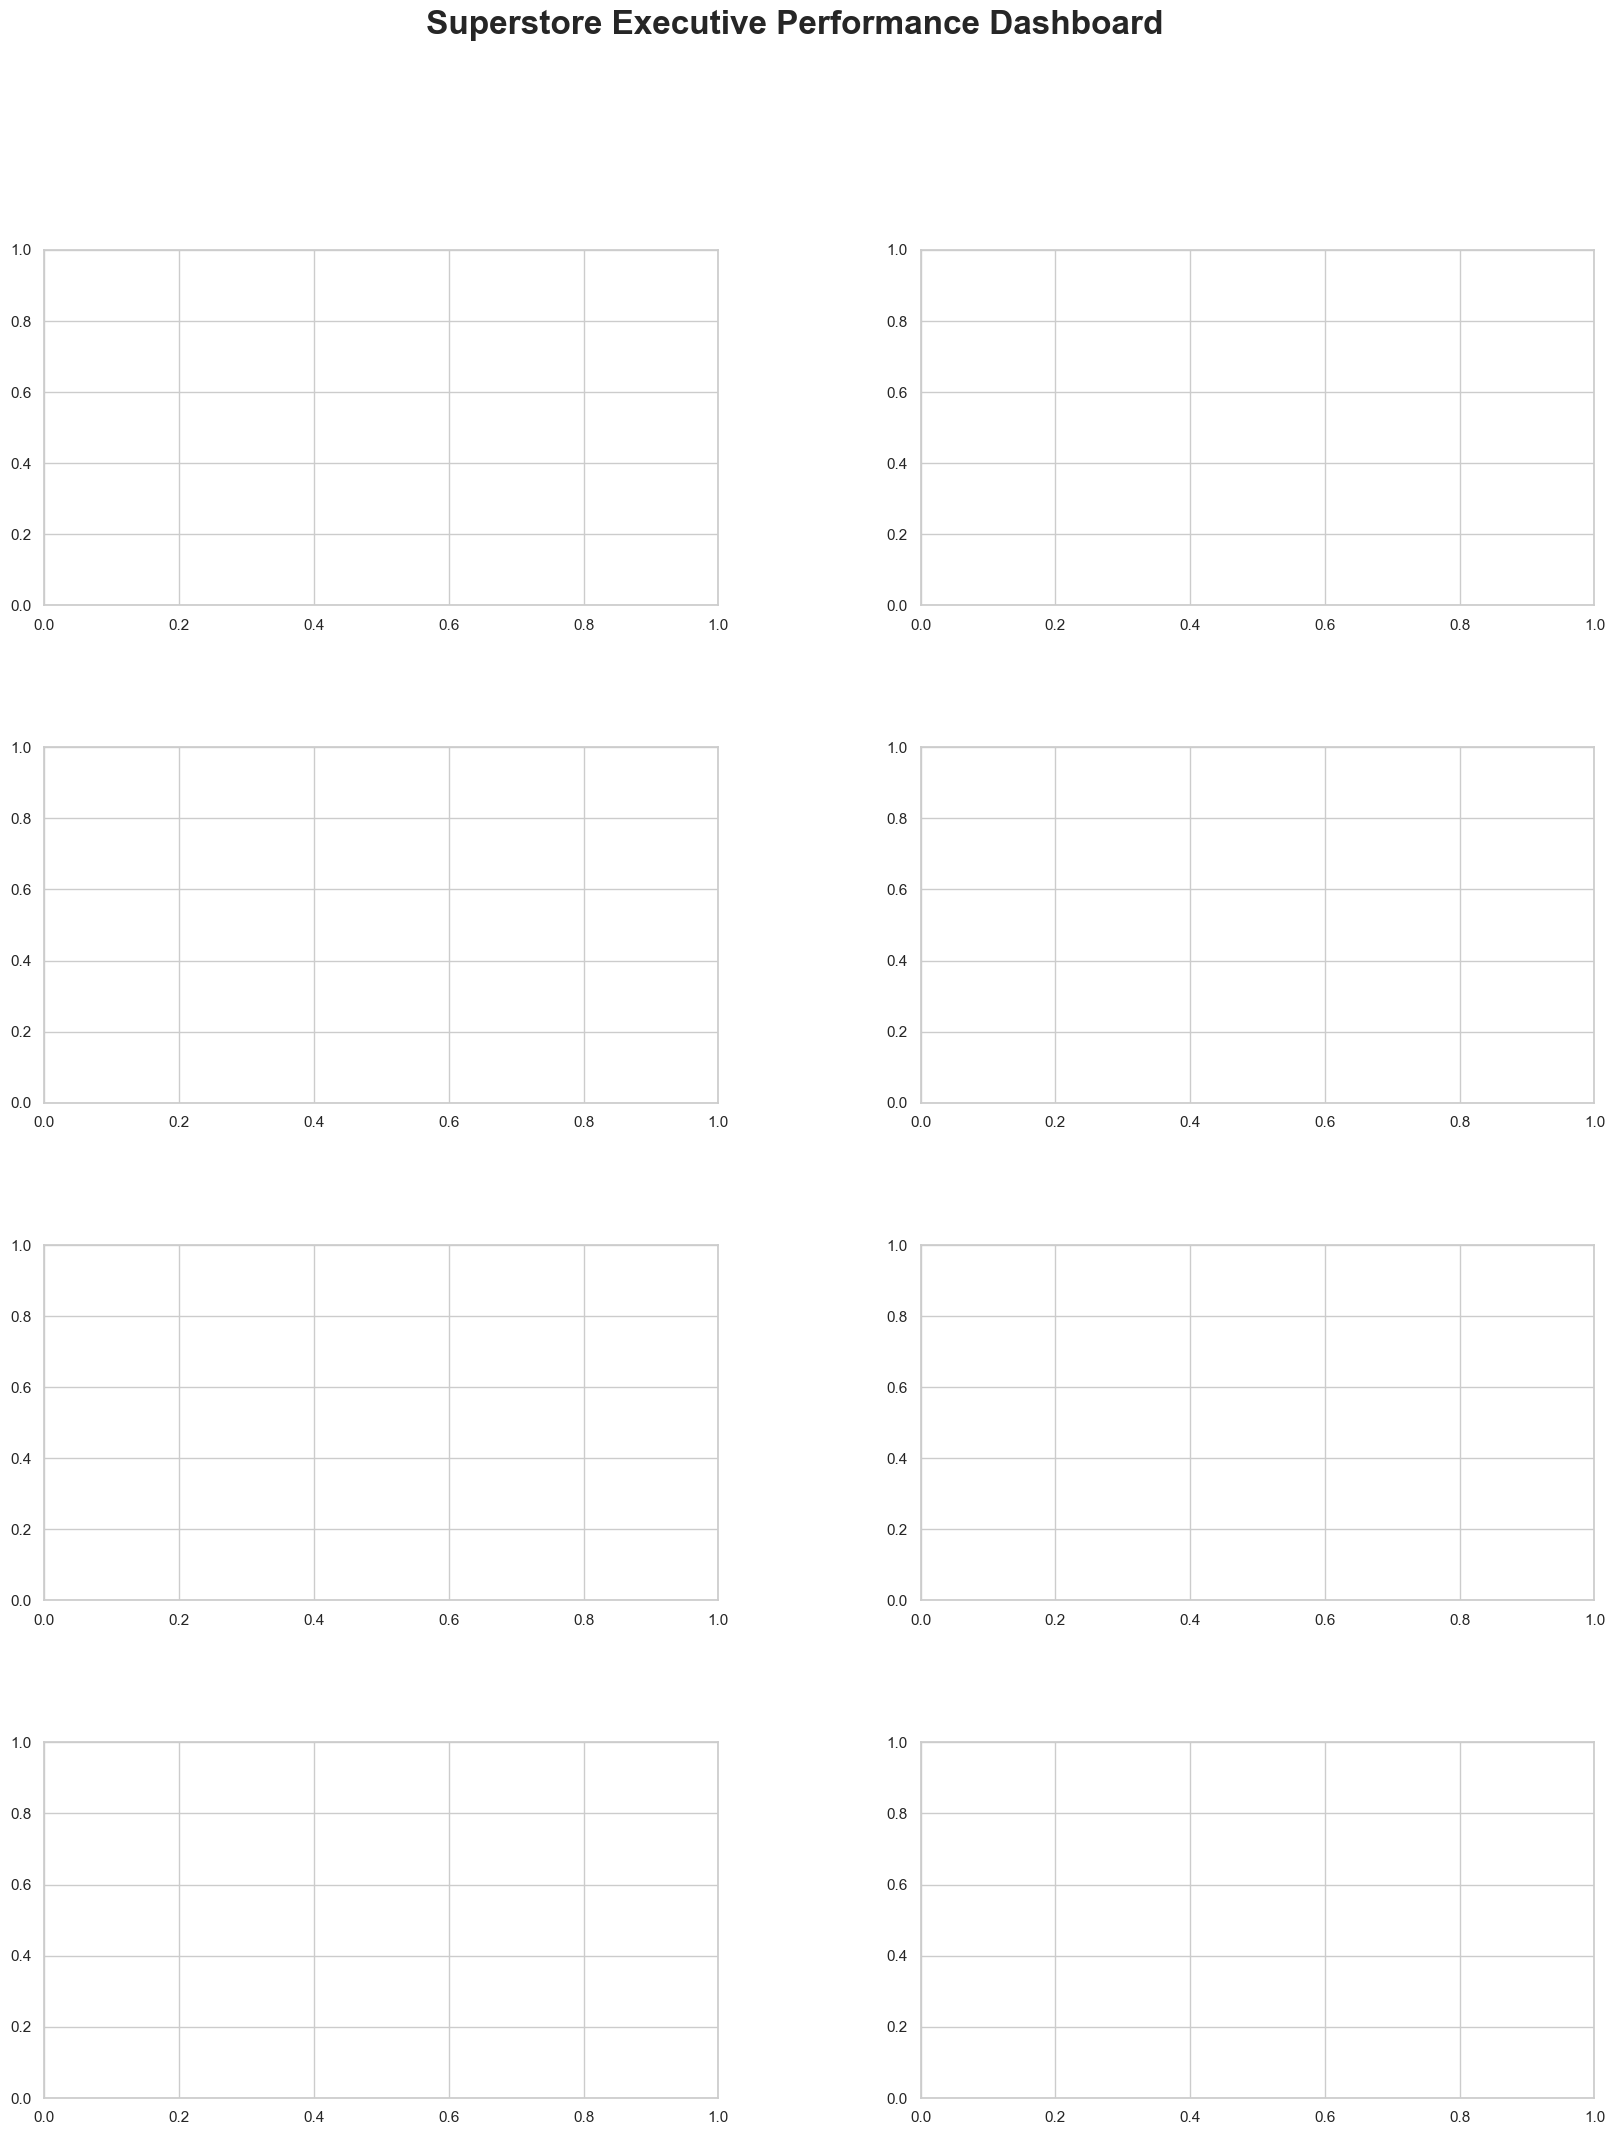

In [ ]:

fig, axes = plt.subplots(4, 2, figsize=(20, 24))
plt.subplots_adjust(hspace=0.4, wspace=0.3) 
fig.suptitle('Superstore Executive Performance Dashboard', fontsize=24, fontweight='bold', y=0.98)
# Visual 1: Monthly Sales & Profit Trend (Line Chart)
if 'df_trend' not in globals():
    df_trend = analyzer.df.copy()

if 'monthly_trend' not in globals():
    monthly_trend = (
        df_trend.groupby('Year_Month')[['Sales', 'Profit']].sum().reset_index()
    )

if 'Year_Month_Str' not in monthly_trend.columns:
    monthly_trend['Year_Month_Str'] = monthly_trend['Year_Month'].astype(str)

if 'seasonal_df' not in globals():
    seasonal_df = analyzer.seasonal_performance().reset_index()

if 'top_states_freq' not in globals():
    top_geo_df = analyzer.top_geo_by_month(top_n=1)
    top_states_freq = top_geo_df[analyzer.geo_col].value_counts().head(10).reset_index()
    top_states_freq.columns = [analyzer.geo_col, 'Months_as_Leader']

if 'customer_df' not in globals():
    customer_df = customer_activity_df.copy()
sns.lineplot(data=monthly_trend, x='Year_Month_Str', y='Sales', marker='o', label='Total Sales', color='#2980b9', ax=axes[0, 0])
sns.lineplot(data=monthly_trend, x='Year_Month_Str', y='Profit', marker='s', label='Total Profit', color='#27ae60', ax=axes[0, 0])
axes[0, 0].set_title('1. Monthly Sales and Profit Performance Trend', fontsize=14)
axes[0, 0].set_ylabel('Amount ($)')
axes[0, 0].set_xlabel('Timeline (Month-Year)')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].legend()

# Visual 2: Top 10 Dominant States (Bar Chart)
# Based on top_geo_by_month(top_n=1)
sns.barplot(data=top_states_freq, x='Months_as_Leader', y=analyzer.geo_col, palette='Blues_r', ax=axes[0, 1])
axes[0, 1].set_title(f'2. Top 10 {analyzer.geo_col}s by Frequency of Ranking #1 in Sales', fontsize=14)
axes[0, 1].set_xlabel('Number of Months as Market Leader')
axes[0, 1].set_ylabel(analyzer.geo_col)

# Visual 3: Total Sales by Season (Pie Chart)
season_order = ['spring', 'summer', 'autumn', 'winter']
seasonal_df['Season'] = pd.Categorical(seasonal_df['Season'], categories=season_order, ordered=True)
seasonal_sort = seasonal_df.sort_values('Season')

axes[1, 0].pie(seasonal_sort['total_sales'], labels=seasonal_sort['Season'].str.title(),
        autopct='%1.1f%%', startangle=140, colors=['#81ecec', '#fab1a0', '#ffeaa7', '#74b9ff'],
        wedgeprops={'edgecolor': 'white'})
axes[1, 0].set_title('3. Share of Total Sales by Season', fontsize=14)


# Visual 4: Sales vs Profit by Season (Grouped Bar Chart)
season_melt = seasonal_df.melt(id_vars='Season', value_vars=['total_sales', 'total_profit'],
                                var_name='Metric', value_name='Amount')

sns.barplot(data=season_melt, x='Season', y='Amount', hue='Metric', order=season_order,
            palette=['#3498db', '#2ecc71'], ax=axes[1, 1])
axes[1, 1].set_title('4. Seasonal Revenue vs Profitability', fontsize=14)
axes[1, 1].set_ylabel('Amount ($)')
axes[1, 1].set_xlabel('Season')
axes[1, 1].legend(labels=['Total Sales', 'Total Profit'])
# ---------------------------------------------------------

# Visual 5: Distribution of Customers by Activity Level (Donut Chart)
activity_counts = customer_df['Activity_Level'].value_counts()
tier_order = ['Low Activity', 'Medium Activity', 'High Activity']
activity_counts = activity_counts.reindex(tier_order)

axes[2, 0].pie(activity_counts, labels=activity_counts.index, autopct='%1.1f%%',
        startangle=90, colors=sns.color_palette("Set2"), wedgeprops={'width': 0.5, 'edgecolor': 'white'})
axes[2, 0].set_title('5. Customer Base Segmentation (Activity Tiers)', fontsize=14)


# Visual 6: Average Spend per Order by Activity Level (Bar Chart)
# Using 'Total_Spent' / 'Total_Orders' from customer_summary
customer_df['Avg_Order_Value_Cust'] = customer_df['Total_Spent'] / customer_df['Total_Orders']
sns.barplot(data=customer_df, x='Activity_Level', y='Avg_Order_Value_Cust', order=tier_order,
            palette='Set2', estimator=np.mean, errorbar=None, ax=axes[2, 1])
axes[2, 1].set_title('6. Average Customer Spend per Order by Activity Tier', fontsize=14)
axes[2, 1].set_ylabel('Average Order Value ($)')
axes[2, 1].set_xlabel('Customer Activity Level')

# (Advanced/Cross Analysis)

# Visual 7: Day of Week Performance (Line Chart with Markers)
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_sales = df_trend.groupby('Day_of_Week')['Sales'].sum().reindex(dow_order).reset_index()

sns.lineplot(data=dow_sales, x='Day_of_Week', y='Sales', marker='o', markersize=10,
                color='#e67e22', linewidth=3, ax=axes[3, 0])
axes[3, 0].set_title('7. Total Sales by Day of the Week', fontsize=14)
axes[3, 0].set_ylabel('Total Sales ($)')
axes[3, 0].set_xlabel('Day of Week')
axes[3, 0].grid(True, axis='y', linestyle='--')


# Visual 8: Preferred Segment by Activity Level (Heatmap)
ct = pd.crosstab(customer_df['Preferred_Segment'], customer_df['Activity_Level'], normalize='index')
ct = ct.reindex(columns=tier_order) 

sns.heatmap(ct, annot=True, fmt=".1%", cmap='YlGnBu', cbar_kws={'label': 'Percentage of Segment'}, ax=axes[3, 1])
axes[3, 1].set_title('8. Customer Activity Heatmap by Segment (Normalized)', fontsize=14)
axes[3, 1].set_xlabel('Activity Level (Based on Order Frequency)')
axes[3, 1].set_ylabel('Customer Segment')

# (Currency Format)
from matplotlib.ticker import StrMethodFormatter
for ax in [axes[0, 0], axes[1, 1], axes[2, 1], axes[3, 0]]:
    ax.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

plt.tight_layout(rect=[0, 0.03, 1, 0.97]) 
plt.show()